<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/06_12_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import torch
from torch.utils.data import TensorDataset, DataLoader
import torchvision.datasets as datasets
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch.nn as nn
from torch.nn import Sequential, Linear, BatchNorm1d, BatchNorm2d, LeakyReLU, ConvTranspose2d, Tanh, Module, Conv2d, Dropout, Flatten

In [2]:
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
train_images = mnist_train.data.clone().detach().to(torch.float32)
train_images = train_images.unsqueeze(1)

train_images = (train_images - 127.5) / 127.5

BATCH_SIZE = 256
dataset = TensorDataset(train_images)
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.36MB/s]


In [3]:
class Reshape(Module):
    def __init__(self, *shape):
        super(Reshape, self).__init__()
        self.shape = shape

    def forward(self, x):
        return x.view(x.size(0), *self.shape)

def make_generator_model(noise_dim):
    model = Sequential(
        Linear(noise_dim, 7 * 7 * 256, bias=False),
        # 정규화
        BatchNorm1d(7 * 7 * 256),
        # 죽은 뉴런 현상 방지
        LeakyReLU(0.2),

        Reshape(256, 7, 7),

        # 역합성곱(이미지 크기는 유지시키면서 채널수 256->128)
        ConvTranspose2d(256, 128, kernel_size=5, stride=1, padding=2, bias=False),
        BatchNorm2d(128),
        LeakyReLU(0.2),

        ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1, bias=False),
        BatchNorm2d(64),
        LeakyReLU(0.2),

        ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1, bias=False),
        Tanh()
    )
    return model

def make_discriminator_model():
    model = Sequential(
        Conv2d(in_channels=1, out_channels=64, kernel_size=5, stride=2, padding=2),
        LeakyReLU(0.2),
        Dropout(0.3),

        Conv2d(in_channels=64, out_channels=128, kernel_size=5, stride=2, padding=2),
        LeakyReLU(0.2),
        Dropout(0.3),

        Flatten(),
        Linear(in_features=7 * 7 * 128, out_features=1)
    )
    return model


In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 연산 장치: {device}")

noise_dim = 100
generator = make_generator_model(noise_dim).to(device)
discriminator = make_discriminator_model().to(device)


generator.apply(weights_init)
discriminator.apply(weights_init)

cross_entropy = nn.BCEWithLogitsLoss()

# betes : 모드 붕괴 방지선(관성 세기 조절하는 파라미터)
generator_optimizer = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))


현재 사용 중인 연산 장치: cuda


In [6]:
def discriminator_loss(real_output, fake_output):
    # real_output : 진짜이미지를 판별자한테 줘서 나온 점수
    # fake_output : 가짜이미지를 판별자한테 줘서 나온 점수
    real_loss = cross_entropy(torch.ones_like(real_output), real_output) # 진짜 이미지를 진짜라고 맞출수록 0에 가까워짐
    fake_loss = cross_entropy(torch.zeros_like(fake_output), fake_output) # 가짜 이미지를 가짜라고 맞출수록 1에 가까워짐
    return real_loss + fake_loss

# 사기 함수(가짜를 진짜로 믿게 만드는)
# 원래 정답지는 0 -> 1로 믿게끔해야되서 오차를 1로 설정
# 속아서 1로 점수를 내면 -> 가짜 정답과 일치해서 -> generator_loss 0
# 안속으면 0로 점수내면 -> 오차범위가 커짐
def generator_loss(fake_output):
    return cross_entropy(torch.ones_like(fake_output), fake_output)

In [7]:
def display_images(model, epoch, test_input):
    model.eval()
    with torch.no_grad():
        pred = model(test_input)

    pred = pred.cpu().numpy()
    plt.figure(figsize=(4, 4))

    for i in range(pred.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = pred[i, 0, :, :]

        # Tanh [-1, 1] 출력을 [0, 1] 범위로 복원
        img_restored = (img + 1.0) / 2.0

        import numpy as np
        img_restored = np.clip(img_restored, 0.0, 1.0)

        plt.imshow(img_restored, cmap='gray')

    plt.suptitle(f"Epoch {epoch}", fontsize=12)
    plt.tight_layout()
    plt.show()

In [8]:
def train_step(images):
    current_batch_size = images.size(0)
    # 노이즈를 매번 완벽한 정규분포로 전달
    noise = torch.randn(current_batch_size, noise_dim, device=images.device)

    # 판별자 학습
    discriminator_optimizer.zero_grad()
    generated_images = generator(noise)

    real_output = discriminator(images)
    fake_output = discriminator(generated_images.detach())

    disc_loss = discriminator_loss(real_output, fake_output)
    disc_loss.backward()
    discriminator_optimizer.step()

    # 생성자 학습
    generator_optimizer.zero_grad()
    fake_output_for_gen = discriminator(generated_images)

    gen_loss = generator_loss(fake_output_for_gen)
    gen_loss.backward()
    generator_optimizer.step()

    return gen_loss.item(), disc_loss.item()

def train(dataloader, epochs):
    seed = torch.randn(16, noise_dim, device=device)

    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        start = time.time()
        print(f'\nepoch : {epoch + 1}')

        for image_batch in tqdm(dataloader, desc=f"Epoch {epoch+1}"):
            images = image_batch[0].to(device)
            train_step(images)

        if (epoch + 1) % 5 == 0:
            display_images(generator, epoch + 1, seed)
            generator.train()

        print(f'Time for epoch {epoch + 1} : {time.time() - start:.2f}sec')


epoch : 1


Epoch 1: 100%|██████████| 235/235 [00:14<00:00, 16.02it/s]


Time for epoch 1 : 14.67sec

epoch : 2


Epoch 2: 100%|██████████| 235/235 [00:13<00:00, 17.67it/s]


Time for epoch 2 : 13.30sec

epoch : 3


Epoch 3: 100%|██████████| 235/235 [00:13<00:00, 17.16it/s]


Time for epoch 3 : 13.70sec

epoch : 4


Epoch 4: 100%|██████████| 235/235 [00:14<00:00, 16.45it/s]


Time for epoch 4 : 14.29sec

epoch : 5


Epoch 5: 100%|██████████| 235/235 [00:14<00:00, 16.49it/s]


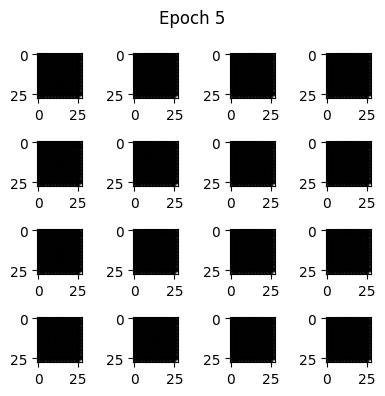

Time for epoch 5 : 15.72sec

epoch : 6


Epoch 6: 100%|██████████| 235/235 [00:14<00:00, 16.51it/s]


Time for epoch 6 : 14.24sec

epoch : 7


Epoch 7: 100%|██████████| 235/235 [00:14<00:00, 16.34it/s]


Time for epoch 7 : 14.39sec

epoch : 8


Epoch 8: 100%|██████████| 235/235 [00:14<00:00, 16.27it/s]


Time for epoch 8 : 14.45sec

epoch : 9


Epoch 9: 100%|██████████| 235/235 [00:14<00:00, 16.50it/s]


Time for epoch 9 : 14.25sec

epoch : 10


Epoch 10: 100%|██████████| 235/235 [00:14<00:00, 16.51it/s]


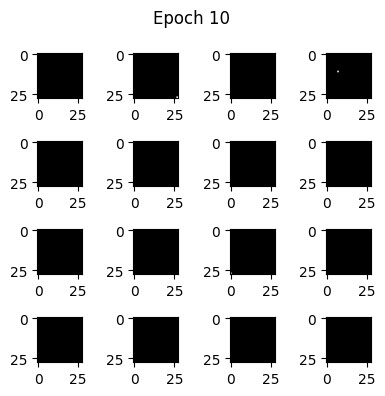

Time for epoch 10 : 15.29sec

epoch : 11


Epoch 11: 100%|██████████| 235/235 [00:14<00:00, 16.49it/s]


Time for epoch 11 : 14.25sec

epoch : 12


Epoch 12: 100%|██████████| 235/235 [00:14<00:00, 16.51it/s]


Time for epoch 12 : 14.24sec

epoch : 13


Epoch 13: 100%|██████████| 235/235 [00:14<00:00, 16.49it/s]


Time for epoch 13 : 14.26sec

epoch : 14


Epoch 14: 100%|██████████| 235/235 [00:14<00:00, 16.43it/s]


Time for epoch 14 : 14.31sec

epoch : 15


Epoch 15: 100%|██████████| 235/235 [00:14<00:00, 16.12it/s]


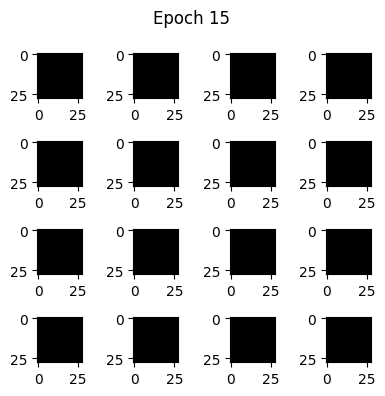

Time for epoch 15 : 15.61sec

epoch : 16


Epoch 16: 100%|██████████| 235/235 [00:14<00:00, 16.48it/s]


Time for epoch 16 : 14.26sec

epoch : 17


Epoch 17: 100%|██████████| 235/235 [00:14<00:00, 16.49it/s]


Time for epoch 17 : 14.26sec

epoch : 18


Epoch 18: 100%|██████████| 235/235 [00:14<00:00, 16.49it/s]


Time for epoch 18 : 14.26sec

epoch : 19


Epoch 19: 100%|██████████| 235/235 [00:14<00:00, 16.51it/s]


Time for epoch 19 : 14.24sec

epoch : 20


Epoch 20: 100%|██████████| 235/235 [00:14<00:00, 16.27it/s]


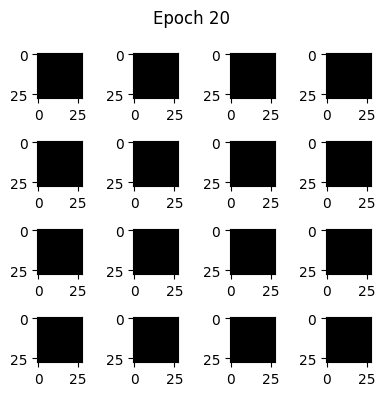

Time for epoch 20 : 15.30sec

epoch : 21


Epoch 21: 100%|██████████| 235/235 [00:14<00:00, 16.50it/s]


Time for epoch 21 : 14.24sec

epoch : 22


Epoch 22: 100%|██████████| 235/235 [00:14<00:00, 16.49it/s]


Time for epoch 22 : 14.26sec

epoch : 23


Epoch 23: 100%|██████████| 235/235 [00:14<00:00, 16.50it/s]


Time for epoch 23 : 14.24sec

epoch : 24


Epoch 24: 100%|██████████| 235/235 [00:14<00:00, 16.32it/s]


Time for epoch 24 : 14.40sec

epoch : 25


Epoch 25: 100%|██████████| 235/235 [00:14<00:00, 16.51it/s]


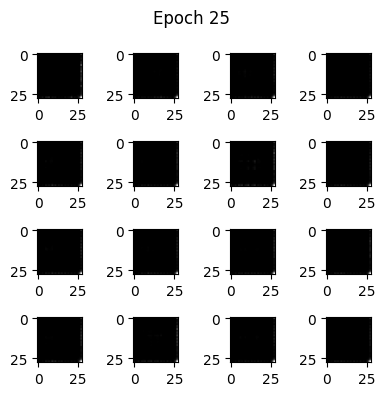

Time for epoch 25 : 15.11sec

epoch : 26


Epoch 26: 100%|██████████| 235/235 [00:14<00:00, 16.51it/s]


Time for epoch 26 : 14.24sec

epoch : 27


Epoch 27: 100%|██████████| 235/235 [00:14<00:00, 16.48it/s]


Time for epoch 27 : 14.26sec

epoch : 28


Epoch 28: 100%|██████████| 235/235 [00:14<00:00, 16.32it/s]


Time for epoch 28 : 14.40sec

epoch : 29


Epoch 29: 100%|██████████| 235/235 [00:14<00:00, 16.51it/s]


Time for epoch 29 : 14.24sec

epoch : 30


Epoch 30: 100%|██████████| 235/235 [00:14<00:00, 16.50it/s]


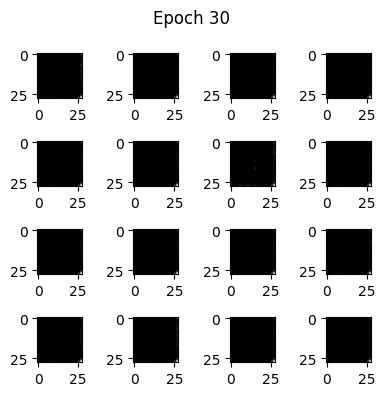

Time for epoch 30 : 15.12sec


In [9]:
if __name__ == '__main__':
    EPOCHES = 30
    train(train_loader, EPOCHES)

In [9]:
# 다른 이미지 데이터셋으로 파이토치로 GAN 성능평가해보기
#